In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import os

In [34]:
tamu_path = Path("../../../2021TXPowerOutage")
load_data = pd.read_csv(tamu_path/"data/ercot_load_forecast.csv", 
            # parse_dates=['DeliveryDate','HourEnding'], 
            # parse_dates={"datetime": ['DeliveryDate','HourEnding']}, 
            # date_format="%m/%d/%Y %H:%M",
            # index_col='datetime'
            )
load_data

,DeliveryDate,HourEnding,Coast,East,FarWest,North,NorthCentral,SouthCentral,Southern,West,SystemTotal,Model,InUseFlag,DSTFlag
0,02/14/2021,1:00,12268.6270,2392.6638,3804.5608,1268.0095,18638.8320,9323.9980,4920.3599,1988.5255,54605.5765,A3,N,N
1,02/14/2021,1:00,12084.2939,2468.4719,3727.1865,1282.3418,18873.1055,9861.7646,4813.7827,2020.0406,55130.9875,A6,N,N
2,02/14/2021,1:00,12177.0000,2444.0000,3474.0000,1320.0000,18868.0000,10224.0000,4878.0000,1976.0000,55361.0000,E,N,N
3,02/14/2021,1:00,12058.0000,2391.0000,3435.0000,1300.0000,18834.0000,10085.0000,4813.0000,1921.0000,54837.0000,E1,Y,N
4,02/14/2021,1:00,12059.0000,2398.0000,3434.0000,1297.0000,18822.0000,10082.0000,4823.0000,1916.0000,54831.0000,E2,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1339,02/21/2021,24:00,9938.0000,1545.0000,3567.0000,879.0000,11391.0000,5677.0000,2764.0000,1402.0000,37163.0000,E,N,N
1340,02/21/2021,24:00,10033.0000,1547.0000,3582.0000,937.0000,12107.0000,5661.0000,2809.0000,1433.0000,38109.0000,E1,N,N
1341,02/21/2021,24:00,8287.0000,1432.0000,3548.0000,932.0000,11795.0000,5398.0000,2788.0000,1441.0000,35621.0000,E2,N,N
1342,02/21/2021,24:00,10491.0000,1364.0000,3517.0000,955.0000,11686.0000,5451.0000,2741.0000,1371.0000,37576.0000,E3,N,N


In [36]:
load_data['datetime'] = pd.to_datetime(load_data['DeliveryDate'] + " " + (load_data['HourEnding'].str.replace(":00","").astype('int')-1).astype(str),
                                       format="%m/%d/%Y %H")
load_data = load_data.set_index('datetime').drop(columns=['DeliveryDate','HourEnding'])

<Axes: xlabel='datetime'>

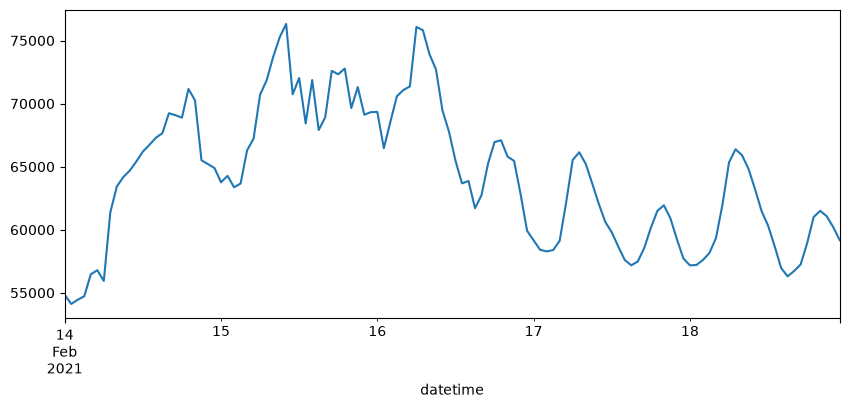

In [48]:
load_data.loc[load_data['InUseFlag']=='Y'].loc[:'2021-02-18', 'SystemTotal'].plot(figsize=(10,4))

<Axes: xlabel='datetime'>

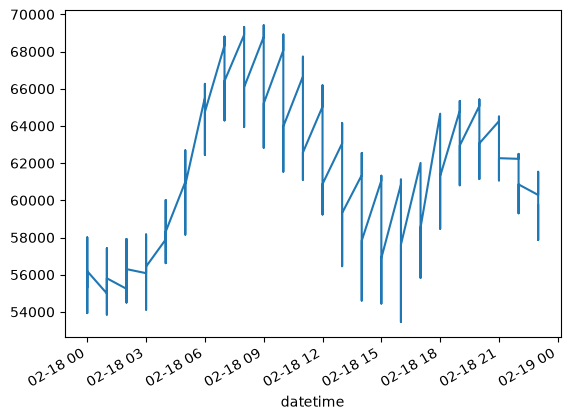

In [41]:
load_data.loc['2021-02-18', 'SystemTotal'].plot()